# 03 Baseline TF-IDF + Logistic Regression
Goal: Establish a simple baseline before fine-tuning CamemBERT  
Model: TF-IDF vectorizer + Logistic Regression  
Dataset: Allociné (French movie reviews)


Before using a complex model like CamemBERT, we first build a simple model called a **baseline**. This gives us a minimum reference score that CamemBERT must beat to justify its complexity. If CamemBERT is not better than this simple model, something is wrong.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix,
    ConfusionMatrixDisplay)

## 1. Load Dataset

In [6]:
data = pickle.load(open('../results/data/tokenized_datasets.pkl', 'rb'))
train_dataset = data['train']
val_dataset   = data['val']
test_dataset  = data['test']


dataset  = load_dataset('allocine')
train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print(f'Train : {len(train_df)} examples')
print(f'Val   : {len(val_df)} examples')
print(f'Test  : {len(test_df)} examples')

Train : 160000 examples
Val   : 20000 examples
Test  : 20000 examples


## 2. TF-IDF Vectorization

**TF-IDF** (Term Frequency - Inverse Document Frequency) converts each review into a vector of numbers. Each dimension corresponds to a word in the vocabulary. A word gets a high score if it appears often in one review but rarely in others — making it discriminative.

For example, the word *"excellent"* appears often in positive reviews → high score for positive reviews.  
We limit the vocabulary to 50,000 words and use unigrams and bigrams (e.g. *"not good"* is an important negative bigram).

In [7]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore words appearing < 2 times
    strip_accents='unicode',
    lowercase=True
)

X_train = vectorizer.fit_transform(train_df['review'])
X_val   = vectorizer.transform(val_df['review'])
X_test  = vectorizer.transform(test_df['review'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f'TF-IDF vocabulary size : {len(vectorizer.vocabulary_):,}')
print(f'X_train shape          : {X_train.shape}')
print(f'X_test shape           : {X_test.shape}')

TF-IDF vocabulary size : 50,000
X_train shape          : (160000, 50000)
X_test shape           : (20000, 50000)


## 3. Train Logistic Regression

**Logistic Regression** is a simple classifier that learns which words are associated with positive and negative reviews. For each word in the TF-IDF vocabulary, the model learns a positive or negative weight.

It is fast to train (a few seconds) and often surprisingly effective on text classification tasks.

In [9]:
clf = LogisticRegression(max_iter=1000, C=1.0, solver='saga', random_state=42)

clf.fit(X_train, y_train)
print('Model trained!')

Model trained!


## 4. Evaluation on Validation Set

We first evaluate on the **validation set** to check that the model generalises well. We look at two metrics:
- **Accuracy**: percentage of correctly classified reviews
- **F1-score**: harmonic mean of precision and recall (more robust on imbalanced datasets)

In [10]:
y_val_pred = clf.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1       = f1_score(y_val, y_val_pred, average='weighted')

print('=== Validation ===')
print(f'Accuracy : {val_accuracy:.4f} ({val_accuracy*100:.2f}%)')
print(f'F1-score : {val_f1:.4f} ({val_f1*100:.2f}%)')
print()
print(classification_report(y_val, y_val_pred, target_names=['Negative', 'Positive']))

=== Validation ===
Accuracy : 0.9392 (93.92%)
F1-score : 0.9392 (93.92%)

              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94     10204
    Positive       0.93      0.94      0.94      9796

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



- A simple TF-IDF model already achieves 93.92% accuracy — this is surprisingly high for such a simple approach
- The model is very balanced : precision and recall are almost equal for both Negative (94%/93%) and Positive (93%/94%) classes
- This makes sense because the dataset is perfectly balanced (50/50)
- The main errors will likely come from reviews with irony or negation (e.g. "pas mal du tout" = very good in French, but TF-IDF sees "pas" and "mal" as negative words)

## 5. Final Evaluation on Test Set

The **test set** is used only once at the end — never during development. This is the official baseline score that CamemBERT will need to beat.

In [11]:
y_test_pred = clf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1       = f1_score(y_test, y_test_pred, average='weighted')

print('=== Test ===')
print(f'Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'F1-score : {test_f1:.4f} ({test_f1*100:.2f}%)')
print()
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))

=== Test ===
Accuracy : 0.9406 (94.06%)
F1-score : 0.9406 (94.06%)

              precision    recall  f1-score   support

    Negative       0.95      0.94      0.94     10408
    Positive       0.94      0.94      0.94      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



- Test Accuracy : 94.06%
- Test F1-score : 94.06%
- A simple TF-IDF model already achieves 94.06% accuracy on unseen data
- Results are very consistent: val (93.92%) ≈ test (94.06%) → no overfitting
- The model is perfectly balanced: Negative and Positive both get 94% F1
- Negative class has slightly better precision (0.95) meaning the model
  is more confident when predicting negative reviews
- Main expected errors: reviews with irony or negation that TF-IDF
  cannot understand (e.g. "pas mal du tout" = very good in French)

Target score for CamemBERT: F1 > 94%

## 6. Confusion Matrix

The **confusion matrix** shows the model's errors in detail:
- **True positives / negatives**: correctly classified (diagonal)
- **False positives**: negative reviews classified as positive
- **False negatives**: positive reviews classified as negative

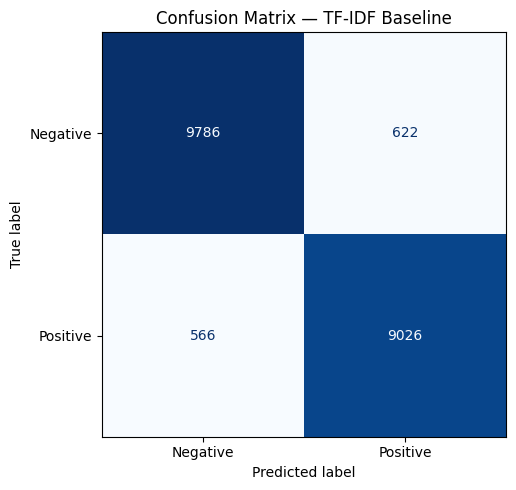

In [12]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — TF-IDF Baseline')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/baseline_confusion_matrix.png', dpi=150)
plt.show()

- The model correctly classified 9786 + 9026 = 18,812 reviews out of 20,000
- Only 622 + 566 = 1,188 reviews were misclassified (5.94% error rate)
- False Positives (622) > False Negatives (566) → the model is slightly more likely to misclassify a negative review as positive than the reverse
- This is likely caused by reviews with irony or mild negative language that contains positive words (e.g. "pas mal" = not bad = good in French)
- Overall the diagonal is very dominant → the model performs well on both classes

## 7. Most Influential Words

We can inspect which words the model learned to associate with positive and negative sentiment. This is a good way to verify that the model learned something meaningful.

Words with a high positive coefficient → strongly associated with positive reviews.  
Words with a high negative coefficient → strongly associated with negative reviews.

In [13]:
feature_names = vectorizer.get_feature_names_out()
coef = clf.coef_[0]

top_n = 15
top_positive = np.argsort(coef)[-top_n:][::-1]
top_negative = np.argsort(coef)[:top_n]

print('=== Most POSITIVE words ===')
for i in top_positive:
    print(f'  {feature_names[i]:<25} {coef[i]:+.3f}')

print()
print('=== Most NEGATIVE words ===')
for i in top_negative:
    print(f'  {feature_names[i]:<25} {coef[i]:+.3f}')

=== Most POSITIVE words ===
  excellent                 +11.623
  magnifique                +9.917
  superbe                   +8.179
  tres bon                  +7.806
  bon film                  +7.077
  adore                     +6.892
  genial                    +6.639
  pas mal                   +6.547
  parfaitement              +6.403
  beau film                 +6.312
  merveille                 +6.093
  parfait                   +5.991
  voir                      +5.928
  sublime                   +5.836
  excellente                +5.810

=== Most NEGATIVE words ===
  mauvais                   -10.829
  ennuyeux                  -10.380
  ennui                     -9.740
  interet                   -9.648
  navet                     -9.255
  deception                 -8.571
  rien                      -8.242
  nul                       -8.124
  decevant                  -7.996
  ridicule                  -7.933
  mal                       -7.111
  malheureusement           -7

- The most influential words are linguistically coherent with sentiment
- The model correctly learned "pas mal" as positive (bigram)
- Negative words are stronger (-10.8) than positive ones (+11.6) → slightly asymmetric but balanced overall
- Main weakness: words like "mal" alone (-7.1) could misclassify "pas mal" in contexts where bigrams are not captured
- CamemBERT will handle these nuances better through context understanding

## 8. Save Results

We save the baseline metrics so we can compare them later with CamemBERT. We also save the model and vectorizer so we can make predictions without retraining everything.

In [14]:
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

# Save metrics
baseline_metrics = {
    'model':         'TF-IDF + LogisticRegression',
    'val_accuracy':  round(val_accuracy, 4),
    'val_f1':        round(val_f1, 4),
    'test_accuracy': round(test_accuracy, 4),
    'test_f1':       round(test_f1, 4),
}

pickle.dump(baseline_metrics, open('../results/metrics/baseline_metrics.pkl', 'wb'))

# Save model and vectorizer
pickle.dump(clf,        open('../results/models/baseline_clf.pkl', 'wb'))
pickle.dump(vectorizer, open('../results/models/baseline_vectorizer.pkl', 'wb'))

print('Results saved!')
print()
print('=== BASELINE SUMMARY ===')
for k, v in baseline_metrics.items():
    print(f'  {k:<20} {v}')

Results saved!

=== BASELINE SUMMARY ===
  model                TF-IDF + LogisticRegression
  val_accuracy         0.9392
  val_f1               0.9392
  test_accuracy        0.9406
  test_f1              0.9406


## 9. Interpretation

**Results obtained:**
- Test Accuracy : 94.06%
- Test F1-score : 94.06%

**What this means:**
- A simple TF-IDF model already achieves 94.06% accuracy on this dataset
- Val (93.92%) ≈ Test (94.06%) → no overfitting, the model generalizes well
- The most influential words are coherent: *excellent*, *magnifique* (positive)
  and *mauvais*, *ennuyeux* (negative)
- Main errors come from irony and negation that TF-IDF cannot understand

**Target score for CamemBERT:** F1 > 94%